# Phase 2 - Community Detection with InfoMap

This notebook studies BC impact through a flow-based perspective: communities are regions that trap random-walk traffic under the Map Equation objective.

| | G_CitOnly | G_BC |
|---|---|---|
| **Type** | Directed, unweighted | Undirected, weighted (BC score) |
| **Edges** | Citation links only | Citations + bibliographic coupling |
| **CD input** | `graph_internal_2020.gpickle` | `graph_combined_2020.gpickle` |
| **InfoMap variant** | Map Equation (directed flow) | Map Equation (w/ weights) |

Scope of this phase:
- derive robust flow-based partitions on both graphs;
- evaluate stochastic stability via multi-run medoid selection;
- quantify fate transitions after BC insertion;
- validate whether transformed flow communities remain semantically coherent;
- statistical validation of merge concentration via Gini permutation test (corpus-level null).

In [1]:
import os, re, time, pickle, textwrap, warnings
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import infomap as infomap_lib
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score
from scipy.stats import entropy as scipy_entropy

from cdlib import NodeClustering, evaluation
from pathlib import Path

BASE_DIR = Path().resolve().parent.parent
GRAPH_DIR = BASE_DIR / "data" / "graph"
INTERNAL_PATH = GRAPH_DIR / "graph_internal_2020.gpickle"
COMBINED_PATH = GRAPH_DIR / "graph_combined_2020.gpickle"

OUTPUT_DIR = Path().resolve() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

N_RUN         = 100
TOP_N_COMMS   = 100
TOP_K         = 5
MIN_COMM_SIZE = 20

## Graph loading

In [2]:
def load_graph(filepath: str):
    with open(filepath, 'rb') as fh:
        return pickle.load(fh)

G_CitOnly = load_graph(INTERNAL_PATH)
G_BC      = load_graph(COMBINED_PATH)

for u, v, d in G_BC.edges(data=True):
    if 'weight' not in d:
        d['weight'] = 1.0

w = [d['weight'] for _, _, d in G_BC.edges(data=True)]

print(f"G_CitOnly  {G_CitOnly.number_of_nodes():>7,} nodes  {G_CitOnly.number_of_edges():>8,} edges  (directed, unweighted)")
print(f"G_BC  {G_BC.number_of_nodes():>7,} nodes  {G_BC.number_of_edges():>8,} edges  "
      f"(undirected, weighted)  median_w={np.median(w):.3f}")

G_CitOnly   55,078 nodes   217,925 edges  (directed, unweighted)
G_BC   57,603 nodes   745,451 edges  (undirected, weighted)  median_w=0.338


## Attribute statistics

In [4]:
def _split_labels(raw_value):
    return [p.strip() for p in re.split(r';\s*', str(raw_value)) if p.strip()]

def _extract_l2(counter):
    l2 = Counter()
    for label, count in counter.items():
        if re.match(r'^\d{2}', label):
            l2[label[:2]] += count
    return l2

def compute_attr_stats(G, attributes=('FOS', 'SDG')):
    stats = {}
    for attr in attributes:
        counts = Counter()
        n_nodes = 0
        for _, data in G.nodes(data=True):
            val = data.get(attr)
            if not val:
                continue
            n_nodes += 1
            counts.update(_split_labels(val))
        stats[attr] = {'counts': counts, 'n_nodes': n_nodes}
        if attr == 'FOS':
            stats['FOS_L2'] = {'counts': _extract_l2(counts), 'n_nodes': n_nodes}
    return stats

def compare_attr_stats(stats_int, stats_comb, key):
    n_i = stats_int[key]['n_nodes']
    n_c = stats_comb[key]['n_nodes']
    all_labels = sorted(set(stats_int[key]['counts']) | set(stats_comb[key]['counts']))
    rows = []
    for label in all_labels:
        ci = stats_int[key]['counts'].get(label, 0)
        cc = stats_comb[key]['counts'].get(label, 0)
        rows.append({
            'label': label,
            'int_cnt': ci,  'int_pct': ci / n_i * 100 if n_i else 0,
            'comb_cnt': cc, 'comb_pct': cc / n_c * 100 if n_c else 0,
        })
    return pd.DataFrame(rows)

In [5]:
fos_stats_path = OUTPUT_DIR / 'infomap_FOS_stats.csv'
sdg_stats_path = OUTPUT_DIR / 'infomap_SDG_stats.csv'

s_int  = compute_attr_stats(G_CitOnly)
s_comb = compute_attr_stats(G_BC)

pd.concat([
    compare_attr_stats(s_int, s_comb, 'FOS').assign(level='detail'),
    compare_attr_stats(s_int, s_comb, 'FOS_L2').assign(level='L2'),
], ignore_index=True).to_csv(fos_stats_path, index=False)

compare_attr_stats(s_int, s_comb, 'SDG') \
    .sort_values('int_cnt', ascending=False) \
    .to_csv(sdg_stats_path, index=False)

print(f'{fos_stats_path.name}  {sdg_stats_path.name}  created')

infomap_FOS_stats.csv  infomap_SDG_stats.csv  created


## InfoMap - Map Equation optimization

InfoMap (Rosvall & Bergstrom, 2008) detects communities by minimizing coding length of random-walk
trajectories. Unlike Leiden's modularity optimization, the Map Equation is self-consistent and does
not suffer from the Fortunato-Barthélemy resolution limit — no resolution sweep is needed.

### Protocol
1. Run InfoMap 100 times (seeds 1..100) with `ThreadPoolExecutor` for parallelism.
2. Compute pairwise NMI across all runs.
3. Select the medoid run (highest average agreement).
4. All results persist to `./output/` — rerun loads from disk.

### Interpretation
- High run-to-run NMI indicates stable flow basins.
- A BC-driven decrease in stability reflects boundary rerouting, not loss of structure.
- Modularity is reported as a support metric; codelength is the primary objective.

In [ ]:
"""
InfoMap ensemble with medoid selection + Gini permutation test.
- Parallelized via ThreadPoolExecutor
- Persistent cache in ./output
- Corpus-level null for Gini significance
"""

from concurrent.futures import ThreadPoolExecutor

def _safe_name(s):
    return re.sub(r'[^\w\-.]', '_', str(s))

def _cache_save(path, obj):
    with open(path, 'wb') as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"    Cached: {path}")

def _cache_load(path):
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f"    Loaded: {path}")
    return obj

def compute_nmi_matrix(labels_list, n_workers=10):
    n = len(labels_list)
    mat = np.eye(n)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

    def _nmi(pair):
        i, j = pair
        return i, j, normalized_mutual_info_score(
            labels_list[i], labels_list[j], average_method='arithmetic'
        )

    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        for i, j, v in pool.map(_nmi, pairs):
            mat[i, j] = mat[j, i] = v
    return mat


def select_medoid(nmi_matrix):
    n = nmi_matrix.shape[0]
    avg_nmi = (nmi_matrix.sum(axis=1) - 1.0) / (n - 1)
    return int(np.argmax(avg_nmi)), avg_nmi, nmi_matrix[np.triu_indices(n, k=1)]

def _run_single_infomap(args):
    seed, nodes_list, edges, is_directed = args
    node_to_idx = {n: i for i, n in enumerate(nodes_list)}

    flags = '--directed --silent' if is_directed else '--silent'
    im = infomap_lib.Infomap(flags)

    for u, v, w in edges:
        im.addLink(node_to_idx[u], node_to_idx[v], w)

    im.run(seed=seed)

    comm_dict = defaultdict(list)
    for node in im.tree:
        if node.isLeaf:
            comm_dict[node.moduleIndex()].append(node.physicalId)
    communities = [sorted(idxs) for idxs in comm_dict.values()]

    labels = np.full(len(nodes_list), -1, dtype=np.int32)
    for cid, comm in enumerate(communities):
        for idx in comm:
            labels[idx] = cid

    return seed, labels, communities


# ──────────────────────────────────────────────
# Ensemble runner + cache
# ──────────────────────────────────────────────

def run_infomap_ensemble(G_nx, graph_name, is_directed=True, weight_attr='weight',
                         n_runs=100, base_seed=1, n_workers=10,
                         cache_dir=OUTPUT_DIR, force=False):
    cache_file = os.path.join(
        cache_dir,
        f"infomap_{_safe_name(graph_name)}_r{n_runs}.pkl"
    )
    if not force and os.path.exists(cache_file):
        cached = _cache_load(cache_file)
        mod_graph = G_nx.to_undirected() if is_directed else G_nx
        clustering = NodeClustering(
            cached['medoid_communities'], graph=mod_graph, method_name='infomap'
        )
        print(f"  Medoid #comms: {cached['stats']['medoid_n_communities']} | "
              f"Q: {cached['stats']['medoid_modularity']:.4f} | "
              f"NMI mean: {cached['stats']['nmi_mean']:.4f}")
        return clustering, cached['stats']

    t0 = time.time()
    nodes_list = list(G_nx.nodes())

    # Pre-extract edges (avoids re-iterating the graph per run)
    edges = []
    for u, v, data in G_nx.edges(data=True):
        w = data.get(weight_attr, 1.0) if not is_directed else 1.0
        edges.append((u, v, w))

    print(f"--- InfoMap ensemble: {graph_name} ---")
    print(f"    Runs: {n_runs} | Directed: {is_directed} | Workers: {n_workers}")

    args = [(seed, nodes_list, edges, is_directed)
            for seed in range(base_seed, base_seed + n_runs)]

    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        raw_results = list(pool.map(_run_single_infomap, args))

    print(f"    InfoMap runs: {time.time() - t0:.1f}s")

    mod_graph = G_nx.to_undirected() if is_directed else G_nx

    results = []
    for seed, labels, ig_communities in raw_results:
        communities = [[nodes_list[i] for i in comm] for comm in ig_communities]
        results.append({
            'seed': seed, 'labels': labels,
            'communities': communities,
            'clustering': NodeClustering(communities, graph=mod_graph, method_name='infomap'),
            'n_communities': len(communities)
        })

    t_nmi = time.time()
    nmi_matrix = compute_nmi_matrix([r['labels'] for r in results], n_workers=n_workers)
    print(f"    NMI matrix: {time.time() - t_nmi:.1f}s")

    medoid_idx, avg_nmi, nmi_vals = select_medoid(nmi_matrix)
    medoid = results[medoid_idx]
    medoid_mod = evaluation.newman_girvan_modularity(mod_graph, medoid['clustering']).score

    print(f"  NMI  min/mean/max/std : {nmi_vals.min():.4f} / {nmi_vals.mean():.4f} / {nmi_vals.max():.4f} / {nmi_vals.std():.4f}")
    print(f"  Medoid seed           : {medoid['seed']}  (idx {medoid_idx})")
    print(f"  Medoid avg NMI        : {avg_nmi[medoid_idx]:.4f}  |  #comms: {medoid['n_communities']}")
    print(f"  Modularity            : {medoid_mod:.4f}  |  Elapsed: {time.time() - t0:.1f}s\n")

    stats = {
        'graph_name': graph_name, 'n_runs': n_runs,
        'nmi_min': float(nmi_vals.min()), 'nmi_max': float(nmi_vals.max()),
        'nmi_mean': float(nmi_vals.mean()), 'nmi_std': float(nmi_vals.std()),
        'medoid_idx': medoid_idx, 'medoid_seed': medoid['seed'],
        'medoid_avg_nmi': float(avg_nmi[medoid_idx]),
        'medoid_n_communities': medoid['n_communities'],
        'medoid_modularity': float(medoid_mod),
        'nmi_matrix': nmi_matrix,
    }

    _cache_save(cache_file, {
        'medoid_communities': medoid['communities'],
        'stats': stats,
    })

    return medoid['clustering'], stats


# ──────────────────────────────────────────────
# Gini concentration + corpus-level permutation test + cache
# ──────────────────────────────────────────────

def gini_concentration(labels):
    """Gini impurity (1 - Herfindahl): G -> 0 = one class dominates, G -> 1 = uniform."""
    labels = np.asarray(labels)
    labels = labels[labels != '']
    if len(labels) == 0:
        return np.nan
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return 1.0 - np.sum(p ** 2)


def build_corpus_fos_pool(G, attr='FOS', level='sub'):
    """Flat array of all FOS labels across all nodes — used as null distribution."""
    pattern = re.compile(r'^\d{4}\s') if level == 'sub' else re.compile(r'^\d{2}\s')
    all_labels = []
    for _, data in G.nodes(data=True):
        val = data.get(attr)
        if not val:
            continue
        parts = [p.strip() for p in str(val).split(';') if p.strip()]
        all_labels.extend(p for p in parts if pattern.match(p))
    return np.array(all_labels)


def gini_permutation_test(merge_labels, corpus_pool, n_permutations=1000, seed=42):
    """
    Test: is merge more concentrated than a random sample from the corpus?
    Low Gini = dominated by few disciplines. p = P(null <= observed), one-sided.
    """
    rng = np.random.default_rng(seed)
    merge_labels = np.asarray(merge_labels)

    clean_labels = merge_labels[merge_labels != '']
    if len(clean_labels) == 0:
        return {'observed_gini': np.nan, 'p_value': np.nan, 'significant': False}

    n_draw = len(clean_labels)
    observed = gini_concentration(clean_labels)

    null_ginis = np.empty(n_permutations)
    for i in range(n_permutations):
        sample = rng.choice(corpus_pool, size=n_draw, replace=True)
        null_ginis[i] = gini_concentration(sample)

    p_value = np.mean(null_ginis <= observed)

    return {
        'observed_gini': float(observed),
        'null_mean': float(null_ginis.mean()),
        'null_std': float(null_ginis.std()),
        'null_p5': float(np.percentile(null_ginis, 5)),
        'null_p95': float(np.percentile(null_ginis, 95)),
        'p_value': float(p_value),
        'significant': p_value < 0.05
    }


def validate_merges(merges, fos_labels_dict, corpus_pool,
                    n_permutations=1000, cache_dir=OUTPUT_DIR, force=False):
    cache_file = os.path.join(cache_dir, f"infomap_gini_validation_{len(merges)}merges.pkl")

    if not force and os.path.exists(cache_file):
        results = _cache_load(cache_file)
        for r in results:
            sig = "✓ SIGNIFICANT" if r['significant'] else "✗ NOT significant"
            print(f"  {r['merge_name']:6s} | n={r['n_nodes']:5d} | "
                  f"Gini={r['observed_gini']:.3f} (obs) vs "
                  f"{r['null_mean']:.3f}±{r['null_std']:.3f} (null) | "
                  f"p={r['p_value']:.4f} | {sig}")
        return results

    results = []
    for merge in merges:
        labels = np.array([fos_labels_dict.get(nid, '') for nid in merge['node_ids']])
        test = gini_permutation_test(labels, corpus_pool, n_permutations=n_permutations)
        test['merge_name'] = merge['name']
        test['n_nodes'] = len(merge['node_ids'])
        test['n_labelled'] = int(np.sum(labels != ''))
        results.append(test)

        sig = "✓ SIGNIFICANT" if test['significant'] else "✗ NOT significant"
        print(f"  {merge['name']:6s} | n={test['n_nodes']:5d} | "
              f"Gini={test['observed_gini']:.3f} (obs) vs "
              f"{test['null_mean']:.3f}±{test['null_std']:.3f} (null) | "
              f"p={test['p_value']:.4f} | {sig}")

    _cache_save(cache_file, results)
    return results

## Ensemble runs

In [7]:
# InfoMap — G_CitOnly (directed, unweighted)
infomap_internal, infomap_internal_stats = run_infomap_ensemble(
    G_nx       = G_CitOnly,
    graph_name = 'G_CitOnly',
    is_directed = True,
    n_runs     = N_RUN
)

--- InfoMap ensemble: G_CitOnly ---
    Runs: 100 | Directed: True | Workers: 10
    InfoMap runs: 223.5s
    NMI matrix: 16.4s
  NMI  min/mean/max/std : 0.8717 / 0.9414 / 0.9903 / 0.0188
  Medoid seed           : 36  (idx 35)
  Medoid avg NMI        : 0.9535  |  #comms: 1496
  Modularity            : 0.8369  |  Elapsed: 245.8s

    Cached: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/infomap_G_CitOnly_r100.pkl


In [8]:
# InfoMap — G_BC (undirected, weighted)
infomap_combined, infomap_combined_stats = run_infomap_ensemble(
    G_nx       = G_BC,
    graph_name = 'G_BC',
    is_directed = False,
    weight_attr = 'weight',
    n_runs     = N_RUN
)

--- InfoMap ensemble: G_BC ---
    Runs: 100 | Directed: False | Workers: 10
    InfoMap runs: 325.6s
    NMI matrix: 9.8s
  NMI  min/mean/max/std : 0.7576 / 0.9100 / 0.9921 / 0.0374
  Medoid seed           : 4  (idx 3)
  Medoid avg NMI        : 0.9336  |  #comms: 1174
  Modularity            : 0.5966  |  Elapsed: 336.6s

    Cached: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/infomap_G_BC_r100.pkl


### Ensemble stability

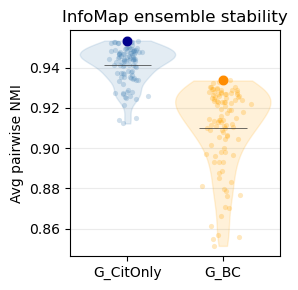

Internal:  μ=0.9414  σ=0.0093  medoid=0.9535
Combined:  μ=0.9100  σ=0.0204  medoid=0.9336


In [9]:
def plot_nmi_stability(stats_int, stats_comb):
    """Light side-by-side violin plots with jitter and medoid markers."""
    def avg_nmi(stats):
        m = stats['nmi_matrix']
        return (m.sum(axis=1) - 1) / (m.shape[0] - 1)

    nmi_int = avg_nmi(stats_int)
    nmi_comb = avg_nmi(stats_comb)

    fig, ax = plt.subplots(figsize=(3, 3))
    data = [nmi_int, nmi_comb]
    positions = [0, 1]

    vp = ax.violinplot(
        data,
        positions=positions,
        widths=1,
        showmeans=True,
        showmedians=False,
        showextrema=False,
    )
    for body, color in zip(vp['bodies'], ['steelblue', 'orange']):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.15)
    vp['cmeans'].set_color('#333333')
    vp['cmeans'].set_linewidth(0.5)

    rng = np.random.default_rng(42)
    jitter_width = 0.1
    ax.scatter(
        rng.normal(positions[0], jitter_width, size=len(nmi_int)),
        nmi_int,
        s=14, color='steelblue', alpha=0.25, linewidths=0,
    )
    ax.scatter(
        rng.normal(positions[1], jitter_width, size=len(nmi_comb)),
        nmi_comb,
        s=14, color='orange', alpha=0.25, linewidths=0,
    )

    med_int = nmi_int[stats_int['medoid_idx']]
    med_comb = nmi_comb[stats_comb['medoid_idx']]
    ax.scatter(positions[0], med_int, s=55, color='darkblue', edgecolors='white', linewidths=0.2, zorder=2)
    ax.scatter(positions[1], med_comb, s=55, color='darkorange', edgecolors='white', linewidths=0.2, zorder=2)

    ax.set_xticks(positions)
    ax.set_xticklabels(['G_CitOnly', 'G_BC'])
    ax.set_ylabel('Avg pairwise NMI')
    ax.set_title('InfoMap ensemble stability')
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    print(f"Internal:  \u03bc={nmi_int.mean():.4f}  \u03c3={nmi_int.std():.4f}  medoid={med_int:.4f}")
    print(f"Combined:  \u03bc={nmi_comb.mean():.4f}  \u03c3={nmi_comb.std():.4f}  medoid={med_comb:.4f}")

plot_nmi_stability(infomap_internal_stats, infomap_combined_stats)

### Internal vs combined partition comparison

We align InfoMap partitions on common nodes and compare them with NMI, ARI, VI, and best-match Jaccard.
Goal: measure which communities stay stable and which are reorganized after adding BC edges.

In [10]:
def _entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log(p + 1e-12))

def variation_of_information(labels_a, labels_b):
    """VI = H(A) + H(B) - 2 * I(A,B)."""
    return (_entropy(labels_a) + _entropy(labels_b)
            - 2.0 * mutual_info_score(labels_a, labels_b))

def _partition_to_sets(partition, allowed_nodes=None, min_size=1):
    result = []
    for comm in partition.communities:
        s = set(comm)
        if allowed_nodes is not None:
            s &= allowed_nodes
        if len(s) >= min_size:
            result.append(s)
    return result

### Size distribution

A compact two-panel view highlights structural differences between `G_CitOnly` and `G_BC`:
- rank-size curve on log-log axes
- cumulative node coverage across ranked communities

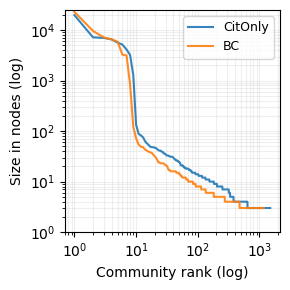


SIZE DISTRIBUTION SUMMARY
  Graph  n_comms  min   max mean median cov_10 cov_50 cov_80 cov_95  k_50%  k_80%  k_95%
CitOnly     1496    3 19750 45.7    3.0  87.8%  90.1%  91.0%  91.3%      4      7    427
     BC     1174    3 22940 55.4    3.0  91.7%  93.2%  93.7%  93.9%      2      5    205


{'CitOnly': {'n': 1496,
  'min': 3,
  'max': 19750,
  'mean': 45.720588235294116,
  'median': 3.0,
  'coverage': {10: 0.8780812304453347,
   50: 0.9013129038860785,
   80: 0.9095148980964356,
   95: 0.912745986724758},
  'nodes_for_thr': {0.5: 4, 0.8: 7, 0.95: 427}},
 'BC': {'n': 1174,
  'min': 3,
  'max': 22940,
  'mean': 55.35689948892674,
  'median': 3.0,
  'coverage': {10: 0.9170013386880856,
   50: 0.9320962008955361,
   80: 0.9373278554832356,
   95: 0.9394051300989398},
  'nodes_for_thr': {0.5: 2, 0.8: 5, 0.95: 205}}}

In [11]:
def plot_size_distribution(partition_a, label_a, partition_b, label_b,
                           color_a='#2563EB', color_b='#F59E0B',
                           title='', thresholds=(0.50, 0.80, 0.95),
                           include_curves=False, save_path=None):
    def _sizes(partition):
        sizes = sorted((len(c) for c in partition.communities), reverse=True)
        if not sizes:
            raise ValueError('Partition has no communities.')
        return np.asarray(sizes, dtype=float)

    def _summary(arr):
        cov = np.cumsum(arr) / arr.sum()
        return {
            'n': len(arr), 'min': int(arr.min()), 'max': int(arr.max()),
            'mean': float(arr.mean()), 'median': float(np.median(arr)),
            'coverage': {k: float(arr[:min(k, len(arr))].sum() / arr.sum()) for k in (10, 50, 80, 95)},
            'nodes_for_thr': {thr: int(np.searchsorted(cov, thr, side='left') + 1) for thr in thresholds},
        }, cov

    sizes_a, sizes_b = _sizes(partition_a), _sizes(partition_b)
    stats_a, _ = _summary(sizes_a)
    stats_b, _ = _summary(sizes_b)

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.plot(np.arange(1, len(sizes_a)+1), sizes_a, color=color_a, lw=1.5, alpha=0.9, label=label_a)
    ax.plot(np.arange(1, len(sizes_b)+1), sizes_b, color=color_b, lw=1.5, alpha=0.9, label=label_b)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(1, 25000)
    ax.set_xlabel('Community rank (log)'); ax.set_ylabel('Size in nodes (log)')
    ax.grid(True, which='both', alpha=0.2); ax.legend(fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    df = pd.DataFrame([
        {'Graph': l, 'n_comms': s['n'], 'min': s['min'], 'max': s['max'],
         'mean': f"{s['mean']:.1f}", 'median': f"{s['median']:.1f}",
         **{f'cov_{k}': f"{s['coverage'][k]:.1%}" for k in (10,50,80,95)},
         **{f'k_{int(t*100)}%': s['nodes_for_thr'][t] for t in thresholds}}
        for l, s in ((label_a, stats_a), (label_b, stats_b))
    ])
    print("\nSIZE DISTRIBUTION SUMMARY")
    print("=" * 130)
    print(df.to_string(index=False))
    return {label_a: stats_a, label_b: stats_b}

plot_size_distribution(
    infomap_internal, 'CitOnly',
    infomap_combined, 'BC',
    color_a='tab:blue', color_b='tab:orange',
    save_path=f"{OUTPUT_DIR}/infomap_size_distribution.png"
)

### Semantic purity

In [12]:
_LEVEL_RE = {
    'macro': re.compile(r'^\d{2}\s'),
    'sub':   re.compile(r'^\d{4}\s'),
}

def parse_labels(val, level='sub'):
    if not val:
        return []
    parts = [p.strip() for p in str(val).split(';') if p.strip()]
    pattern = _LEVEL_RE.get(level)
    return [p for p in parts if pattern.match(p)] if pattern else parts

In [13]:
def compute_semantic_purity(clustering, G, attr='FOS', level='macro', min_size=10):
    def _gini_inequality(counts):
        if len(counts) == 0:
            return 0.0
        s = np.sort(counts.astype(float))
        n = len(s)
        return (2 * np.sum(np.arange(1, n+1) * s)) / (n * s.sum()) - (n+1) / n

    entropies, ginis, sizes = [], [], []
    for comm in clustering.communities:
        if len(comm) < min_size:
            continue
        labels = []
        for node in comm:
            labels.extend(parse_labels(G.nodes[node].get(attr), level=level))
        if not labels:
            continue
        _, counts = np.unique(labels, return_counts=True)
        probs = counts / counts.sum()
        H = scipy_entropy(probs, base=2)
        H_max = np.log2(len(counts)) if len(counts) > 1 else 1.0
        entropies.append(H / H_max if H_max > 0 else 0.0)
        ginis.append(_gini_inequality(counts))
        sizes.append(len(comm))

    sizes = np.array(sizes)
    total = sizes.sum()
    return {
        'entropy': (np.array(entropies) * sizes).sum() / total,
        'gini_inequality': (np.array(ginis) * sizes).sum() / total,
        'n_comms': len(sizes),
    }


def print_purity_comparison(clust_int, clust_comb, G_int, G_comb, min_size=10):
    print("\n" + "=" * 80)
    print("SEMANTIC PURITY ANALYSIS")
    print("=" * 80)
    for key, attr, level in [('FOS_L2', 'FOS', 'macro'), ('FOS', 'FOS', 'sub'), ('SDG', 'SDG', 'all')]:
        p_int  = compute_semantic_purity(clust_int,  G_int,  attr=attr, level=level, min_size=min_size)
        p_comb = compute_semantic_purity(clust_comb, G_comb, attr=attr, level=level, min_size=min_size)
        de = p_comb['entropy'] - p_int['entropy']
        dg = p_comb['gini_inequality'] - p_int['gini_inequality']
        e_verdict = "WORSE" if de > 0.01 else ("BETTER" if de < -0.01 else "SAME")
        g_verdict = "BETTER" if dg > 0.01 else ("WORSE" if dg < -0.01 else "SAME")
        print(f"\n{key}:")
        print(f"  Internal  | Entropy: {p_int['entropy']:.4f} | Gini ineq.: {p_int['gini_inequality']:.4f} | Comms: {p_int['n_comms']}")
        print(f"  Combined  | Entropy: {p_comb['entropy']:.4f} | Gini ineq.: {p_comb['gini_inequality']:.4f} | Comms: {p_comb['n_comms']}")
        print(f"  Delta Combined vs Internal: Entropy {de:+.4f} ({e_verdict}) | Gini ineq. {dg:+.4f} ({g_verdict})")
    print("=" * 80)

print_purity_comparison(infomap_internal, infomap_combined, G_CitOnly, G_BC)


SEMANTIC PURITY ANALYSIS

FOS_L2:
  Internal  | Entropy: 0.4896 | Gini ineq.: 0.6117 | Comms: 182
  Combined  | Entropy: 0.4717 | Gini ineq.: 0.6392 | Comms: 81
  Delta Combined vs Internal: Entropy -0.0179 (BETTER) | Gini ineq. +0.0275 (BETTER)

FOS:
  Internal  | Entropy: 0.5073 | Gini ineq.: 0.8070 | Comms: 182
  Combined  | Entropy: 0.5118 | Gini ineq.: 0.8142 | Comms: 81
  Delta Combined vs Internal: Entropy +0.0045 (SAME) | Gini ineq. +0.0072 (SAME)

SDG:
  Internal  | Entropy: 0.5980 | Gini ineq.: 0.6779 | Comms: 162
  Combined  | Entropy: 0.5723 | Gini ineq.: 0.7075 | Comms: 83
  Delta Combined vs Internal: Entropy -0.0257 (BETTER) | Gini ineq. +0.0295 (BETTER)


### Fate analysis - BC impact within InfoMap

Each community in `infomap_internal` is classified by its outcome in `infomap_combined`.

| Fate | Rule | Interpretation |
|---|---|---|
| stable | best Jaccard >= 0.50 | flow basin mostly preserved |
| merged | >=2 internal communities map to one combined community | BC unifies separated flow regions |
| split | one internal community maps to >=2 combined communities | BC reveals differentiated flow channels |
| dissolved | best Jaccard < 0.20 | no clear counterpart after BC |
| partial | otherwise | mixed restructuring |

Only communities with size >= 20 are included to reduce sensitivity to micro-components.

In [14]:
def get_top_labels(comm, G, attr='FOS', level='sub', top_k=3):
    counter = Counter()
    for node in comm:
        counter.update(parse_labels(G.nodes[node].get(attr), level=level))
    total = sum(counter.values())
    if not total:
        return 'N/A'
    return ' | '.join(f"{k} ({v/total:.0%})" for k, v in counter.most_common(top_k))


def classify_community_fates(part_a, part_b, G,
                              name_a='A', name_b='B',
                              stable_thr=0.5, dissolved_thr=0.20,
                              min_size=50, attr='FOS', level='sub'):
    common = ({n for c in part_a.communities for n in c}
              & {n for c in part_b.communities for n in c})
    a_sets = _partition_to_sets(part_a, common, min_size)
    b_sets = _partition_to_sets(part_b, common, min_size)

    b_to_a_groups = defaultdict(list)
    rows = []

    for a_id, A in enumerate(a_sets):
        overlap = {b_id: len(A & B) / len(A | B)
                   for b_id, B in enumerate(b_sets) if A & B}
        if not overlap:
            rows.append({'a_id': a_id, 'size_a': len(A),
                         'best_jacc': 0.0, 'best_b_id': None,
                         'n_b_touched': 0, 'top_b_frac': 0.0,
                         'top_fos': get_top_labels(A, G, attr=attr, level=level),
                         'fate': 'dissolved'})
            continue

        best_b = max(overlap, key=overlap.get)
        top_b_frac = len(A & b_sets[best_b]) / len(A)
        n_touched = sum(1 for v in overlap.values() if v > 0.05)
        b_to_a_groups[best_b].append(a_id)
        rows.append({'a_id': a_id, 'size_a': len(A),
                     'best_jacc': round(overlap[best_b], 4), 'best_b_id': best_b,
                     'n_b_touched': n_touched,
                     'top_b_frac': round(top_b_frac, 3),
                     'top_fos': get_top_labels(A, G, attr=attr, level=level),
                     'fate': '__pending__'})

    df = pd.DataFrame(rows)
    b_group_size = df['best_b_id'].map(
        lambda bid: len(b_to_a_groups[bid]) if bid is not None else 0
    )
    df['fate'] = np.select(
        [df['fate'] == 'dissolved',
         df['best_jacc'] >= stable_thr,
         b_group_size > 1,
         (df['n_b_touched'] >= 2) & (df['top_b_frac'] < 0.70),
         df['best_jacc'] < dissolved_thr],
        ['dissolved', 'stable', 'merged', 'split', 'dissolved'],
        default='partial',
    )

    merge_events = []
    for b_id, a_ids in b_to_a_groups.items():
        if len(a_ids) < 2:
            continue
        event_comms = [a_sets[i] for i in a_ids]
        fos_profiles = [get_top_labels(c, G, attr=attr, top_k=2, level=level)
                        for c in event_comms]
        b_fos = get_top_labels(b_sets[b_id], G, attr=attr, top_k=3, level=level)
        unique_dom = len({p.split(' | ')[0].split(' (')[0] for p in fos_profiles})
        merge_events.append({
            'b_id': b_id, 'b_size': len(b_sets[b_id]),
            'b_nodes': list(b_sets[b_id]),
            'n_merged': len(a_ids), 'a_sizes': [len(c) for c in event_comms],
            'fos_profiles': fos_profiles, 'b_fos': b_fos,
            'cross_domain': unique_dom > 1,
        })
    merge_events.sort(key=lambda x: x['b_size'], reverse=True)

    map_a = {n: cid for cid, s in enumerate(a_sets) for n in s}
    map_b = {n: cid for cid, s in enumerate(b_sets) for n in s}
    common_nodes = sorted(set(map_a) & set(map_b))
    la = np.array([map_a[n] for n in common_nodes])
    lb = np.array([map_b[n] for n in common_nodes])
    nmi = normalized_mutual_info_score(la, lb, average_method='arithmetic')
    vi = variation_of_information(la, lb)

    print(f'\n{"="*60}')
    print(f'  Fate Analysis: {name_a} -> {name_b}')
    print(f'{"="*60}')
    print(f'  Communities analysed (>={min_size} nodes): {len(df)}')
    print(f'  NMI: {nmi:.4f}  |  VI: {vi:.4f}')
    for fate, grp in df.groupby('fate'):
        pct = len(grp) / len(df) * 100
        print(f'    {fate:<12s} {len(grp):>4d}  ({pct:5.1f}%)  {"#" * int(pct/2)}')
    n_cross = sum(e['cross_domain'] for e in merge_events)
    print(f'\n  Merge events: {len(merge_events)}  |  Cross-domain: {n_cross}')

    return df, merge_events, {'NMI': nmi, 'VI': vi}


def print_merge_report(merge_events, top_n=10):
    print(f'\n{"="*65}')
    print(f'  TOP {top_n} MERGE EVENTS  (components >= 50 nodes)')
    print(f'{"="*65}')
    for i, ev in enumerate(merge_events[:top_n]):
        tag = '[cross-domain]' if ev['cross_domain'] else '[same-domain]'
        print(f'\n  [{i+1}] {tag}  -  {ev["n_merged"]} comms -> 1  (merged size: {ev["b_size"]})')
        print(f'       Merged FOS: {ev["b_fos"]}')
        for j, (fos, sz) in enumerate(zip(ev['fos_profiles'], ev['a_sizes'])):
            print(f'         C{j+1} (n={sz:>5d}): {fos}')

In [15]:
df_fates_infomap, merge_events_infomap, global_infomap = classify_community_fates(
    part_a   = infomap_internal,
    part_b   = infomap_combined,
    G        = G_BC,
    name_a   = 'InfoMap/Internal',
    name_b   = 'InfoMap/Combined',
    attr     = 'FOS',
    level    = 'sub',
    min_size = MIN_COMM_SIZE,
)


  Fate Analysis: InfoMap/Internal -> InfoMap/Combined
  Communities analysed (>=20 nodes): 46
  NMI: 0.7456  |  VI: 1.0046
    dissolved       1  (  2.2%)  #
    merged         26  ( 56.5%)  ############################
    partial         1  (  2.2%)  #
    stable         18  ( 39.1%)  ###################

  Merge events: 5  |  Cross-domain: 4


In [16]:
print_merge_report(merge_events_infomap, top_n=20)


  TOP 20 MERGE EVENTS  (components >= 50 nodes)

  [1] [cross-domain]  -  10 comms -> 1  (merged size: 19664)
       Merged FOS: 0302 clinical medicine (48%) | 0301 basic medicine (26%) | 0303 health sciences (15%)
         C1 (n=15988): 0302 clinical medicine (50%) | 0301 basic medicine (27%)
         C2 (n= 2656): 0302 clinical medicine (33%) | 0301 basic medicine (16%)
         C3 (n=   55): 0501 psychology and cognitive sciences (62%) | 0302 clinical medicine (18%)
         C4 (n=   33): 0302 clinical medicine (64%) | 0301 basic medicine (28%)
         C5 (n=   29): 0302 clinical medicine (74%) | 0501 psychology and cognitive sciences (26%)
         C6 (n=   28): 0403 veterinary science (57%) | 0302 clinical medicine (36%)
         C7 (n=   32): 0302 clinical medicine (69%) | 0301 basic medicine (26%)
         C8 (n=   25): 0302 clinical medicine (100%)
         C9 (n=   22): 0302 clinical medicine (55%) | 0301 basic medicine (36%)
         C10 (n=   20): 0103 physical sciences (7

## Gini permutation test — merge significance

For each merge event, test whether its FOS concentration is significantly higher
than expected from a random sample of the same size drawn from the corpus-wide
FOS distribution.

In [17]:
# Build corpus-level FOS pool for null model
corpus_pool = build_corpus_fos_pool(G_BC, attr='FOS', level='sub')
print(f"Corpus FOS pool: {len(corpus_pool)} labels, {len(np.unique(corpus_pool))} unique")

# Build node -> FOS L4 label dict
fos_labels_dict = {}
for nid, data in G_BC.nodes(data=True):
    fos = data.get('FOS', '')
    parts = [p.strip() for p in str(fos).split(';') if re.match(r'^\d{4}\s', p.strip())]
    fos_labels_dict[nid] = parts[0] if parts else ''

# Convert merge_events_infomap -> format for validate_merges
merges = []
for i, evt in enumerate(merge_events_infomap):
    merges.append({
        'name': f"M{i+1}",
        'node_ids': evt['b_nodes'],
    })

print(f"\nTesting {len(merges)} merge events:")
gini_results = validate_merges(merges, fos_labels_dict, corpus_pool)

sig_count = sum(1 for r in gini_results if r['significant'])
print(f"\n{sig_count}/{len(gini_results)} merges have significant concentration (p < 0.05)")

Corpus FOS pool: 63248 labels, 39 unique

Testing 5 merge events:
  M1     | n=19664 | Gini=0.552 (obs) vs 0.893±0.001 (null) | p=0.0000 | ✓ SIGNIFICANT
  M2     | n= 8035 | Gini=0.783 (obs) vs 0.893±0.002 (null) | p=0.0000 | ✓ SIGNIFICANT
  M3     | n= 6373 | Gini=0.238 (obs) vs 0.893±0.002 (null) | p=0.0000 | ✓ SIGNIFICANT
  M4     | n= 5829 | Gini=0.714 (obs) vs 0.893±0.002 (null) | p=0.0000 | ✓ SIGNIFICANT
  M5     | n= 2689 | Gini=0.809 (obs) vs 0.893±0.003 (null) | p=0.0000 | ✓ SIGNIFICANT
    Cached: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/infomap_gini_validation_5merges.pkl

5/5 merges have significant concentration (p < 0.05)
